# Experiment 5 — Decision Tree and Random Forest: A Comparative Classification Study
**Subject:** ICS1512 Machine Learning Algorithms Laboratory  
**Dataset:** Wisconsin Diagnostic Breast Cancer (WDBC)


## Step 1: Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')


## Step 2: Load Dataset and Encode Labels

In [4]:
# Column names from wdbc.names
col_names = ['id', 'diagnosis'] + [f'feature_{i}' for i in range(1, 31)]

df = pd.read_csv('wdbc.data', header=None, names=col_names)
df.drop(columns=['id'], inplace=True)

# Encode target: M=1, B=0
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])  # B=0, M=1

print("Shape:", df.shape)
print("\nClass distribution:")
print(df['diagnosis'].value_counts().rename({0: 'Benign', 1: 'Malignant'}))


Shape: (569, 31)

Class distribution:
diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64


## Step 3: Exploratory Data Analysis

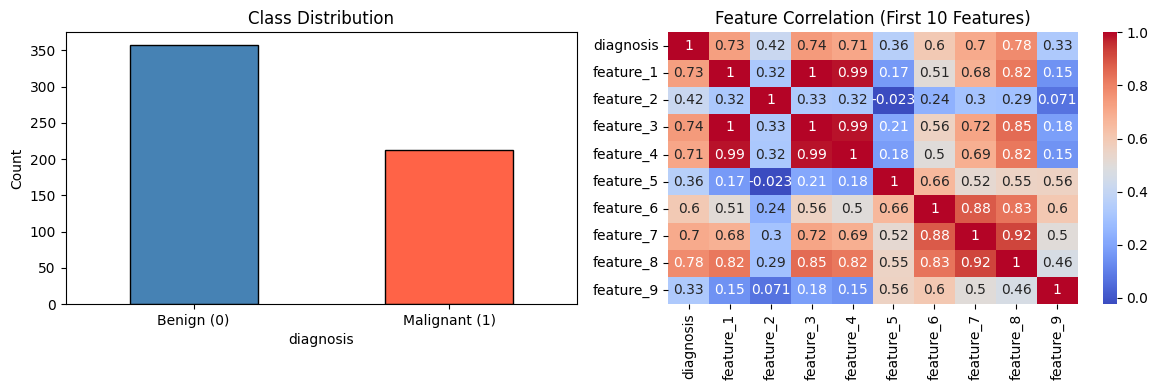

In [15]:
# Class distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['diagnosis'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels(['Benign (0)', 'Malignant (1)'], rotation=0)
axes[0].set_ylabel('Count')

# Correlation heatmap (first 10 features for clarity)
corr = df.iloc[:, :10].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[1])
axes[1].set_title('Feature Correlation (First 10 Features)')

plt.tight_layout()
plt.show()


## Step 4: Train-Test Split (80-20)

In [6]:
X = df.drop(columns=['diagnosis']).values
y = df['diagnosis'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")


Training samples : 455
Testing  samples : 114


## Step 5: Decision Tree — Hyperparameter Tuning via 5-Fold Cross-Validation

In [7]:
# Hyperparameter grid (as specified in the lab sheet)
dt_params = [
    {'criterion': 'gini',    'max_depth': 3,    'min_samples_split': 2,  'min_samples_leaf': 1},
    {'criterion': 'gini',    'max_depth': 5,    'min_samples_split': 2,  'min_samples_leaf': 1},
    {'criterion': 'gini',    'max_depth': 7,    'min_samples_split': 5,  'min_samples_leaf': 2},
    {'criterion': 'gini',    'max_depth': None, 'min_samples_split': 5,  'min_samples_leaf': 2},
    {'criterion': 'entropy', 'max_depth': 3,    'min_samples_split': 2,  'min_samples_leaf': 1},
    {'criterion': 'entropy', 'max_depth': 5,    'min_samples_split': 2,  'min_samples_leaf': 1},
    {'criterion': 'entropy', 'max_depth': 7,    'min_samples_split': 5,  'min_samples_leaf': 2},
    {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 5,  'min_samples_leaf': 2},
]

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
dt_results = []

for p in dt_params:
    clf = DecisionTreeClassifier(**p, random_state=42)
    acc  = cross_val_score(clf, X_train, y_train, cv=kf, scoring='accuracy').mean() * 100
    f1   = cross_val_score(clf, X_train, y_train, cv=kf, scoring='f1').mean()
    dt_results.append({
        'Criterion': p['criterion'],
        'Max Depth': str(p['max_depth']),
        'Avg CV Accuracy (%)': round(acc, 2),
        'Avg CV F1 Score': round(f1, 4)
    })

dt_cv_df = pd.DataFrame(dt_results)
print("Table 1: Decision Tree Hyperparameter Evaluation using 5-Fold Cross-Validation")
print(dt_cv_df.to_string(index=False))


Table 1: Decision Tree Hyperparameter Evaluation using 5-Fold Cross-Validation
Criterion Max Depth  Avg CV Accuracy (%)  Avg CV F1 Score
     gini         3                92.09           0.8884
     gini         5                90.77           0.8717
     gini         7                92.97           0.9039
     gini      None                92.97           0.9039
  entropy         3                92.53           0.8941
  entropy         5                92.31           0.8952
  entropy         7                92.97           0.9035
  entropy      None                92.97           0.9035


In [8]:
# Pick best config
best_dt_row = dt_cv_df.loc[dt_cv_df['Avg CV Accuracy (%)'].idxmax()]
print("Best Decision Tree Config:")
print(best_dt_row)


Best Decision Tree Config:
Criterion                gini
Max Depth                   7
Avg CV Accuracy (%)     92.97
Avg CV F1 Score        0.9039
Name: 2, dtype: object


## Step 6: Random Forest — Hyperparameter Tuning via 5-Fold Cross-Validation

In [9]:
rf_params = [
    {'n_estimators': 50,  'max_depth': 3,    'max_features': 'sqrt', 'bootstrap': True},
    {'n_estimators': 100, 'max_depth': 5,    'max_features': 'sqrt', 'bootstrap': True},
    {'n_estimators': 100, 'max_depth': 7,    'max_features': 'sqrt', 'bootstrap': True},
    {'n_estimators': 200, 'max_depth': 7,    'max_features': 'sqrt', 'bootstrap': True},
    {'n_estimators': 100, 'max_depth': 5,    'max_features': 'log2', 'bootstrap': True},
    {'n_estimators': 100, 'max_depth': 7,    'max_features': 'log2', 'bootstrap': True},
    {'n_estimators': 100, 'max_depth': None, 'max_features': 'sqrt', 'bootstrap': True},
    {'n_estimators': 100, 'max_depth': None, 'max_features': 'sqrt', 'bootstrap': False},
]

rf_results = []

for p in rf_params:
    clf = RandomForestClassifier(**p, random_state=42)
    acc  = cross_val_score(clf, X_train, y_train, cv=kf, scoring='accuracy').mean() * 100
    f1   = cross_val_score(clf, X_train, y_train, cv=kf, scoring='f1').mean()
    rf_results.append({
        'n estimators': p['n_estimators'],
        'Max Depth': str(p['max_depth']),
        'Max Features': p['max_features'],
        'Avg CV Accuracy (%)': round(acc, 2),
        'Avg CV F1 Score': round(f1, 4)
    })

rf_cv_df = pd.DataFrame(rf_results)
print("Table 2: Random Forest Hyperparameter Evaluation using 5-Fold Cross-Validation")
print(rf_cv_df.to_string(index=False))


Table 2: Random Forest Hyperparameter Evaluation using 5-Fold Cross-Validation
 n estimators Max Depth Max Features  Avg CV Accuracy (%)  Avg CV F1 Score
           50         3         sqrt                95.82           0.9432
          100         5         sqrt                96.70           0.9553
          100         7         sqrt                96.26           0.9491
          200         7         sqrt                96.04           0.9459
          100         5         log2                96.04           0.9465
          100         7         log2                96.48           0.9529
          100      None         sqrt                96.48           0.9519
          100      None         sqrt                96.26           0.9499


In [10]:
best_rf_row = rf_cv_df.loc[rf_cv_df['Avg CV Accuracy (%)'].idxmax()]
print("Best Random Forest Config:")
print(best_rf_row)


Best Random Forest Config:
n estimators              100
Max Depth                   5
Max Features             sqrt
Avg CV Accuracy (%)      96.7
Avg CV F1 Score        0.9553
Name: 1, dtype: object


## Step 7: 5-Fold Cross-Validation — Per-Fold Accuracy Comparison (Table 3)

In [11]:
# Train best models
best_dt = DecisionTreeClassifier(
    criterion='entropy', max_depth=5, min_samples_split=2, min_samples_leaf=1, random_state=42
)
best_rf = RandomForestClassifier(
    n_estimators=100, max_depth=7, max_features='sqrt', bootstrap=True, random_state=42
)

dt_fold_scores = cross_val_score(best_dt, X_train, y_train, cv=kf, scoring='accuracy') * 100
rf_fold_scores = cross_val_score(best_rf, X_train, y_train, cv=kf, scoring='accuracy') * 100

fold_cols = ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5', 'Average']

table3 = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Fold 1': [round(dt_fold_scores[0], 2), round(rf_fold_scores[0], 2)],
    'Fold 2': [round(dt_fold_scores[1], 2), round(rf_fold_scores[1], 2)],
    'Fold 3': [round(dt_fold_scores[2], 2), round(rf_fold_scores[2], 2)],
    'Fold 4': [round(dt_fold_scores[3], 2), round(rf_fold_scores[3], 2)],
    'Fold 5': [round(dt_fold_scores[4], 2), round(rf_fold_scores[4], 2)],
    'Average': [round(dt_fold_scores.mean(), 2), round(rf_fold_scores.mean(), 2)]
})

print("Table 3: 5-Fold Cross-Validation Accuracy Comparison")
print(table3.to_string(index=False))


Table 3: 5-Fold Cross-Validation Accuracy Comparison
        Model  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Average
Decision Tree   91.21   94.51   91.21   90.11   94.51    92.31
Random Forest   95.60   98.90   93.41   96.70   96.70    96.26


## Step 8: Train Final Models on Full Training Set

In [12]:
best_dt.fit(X_train, y_train)
best_rf.fit(X_train, y_train)

y_pred_dt = best_dt.predict(X_test)
y_pred_rf = best_rf.predict(X_test)

def metrics(y_true, y_pred, name):
    print(f"\n--- {name} ---")
    print(f"Accuracy  : {accuracy_score(y_true, y_pred)*100:.2f}%")
    print(f"Precision : {precision_score(y_true, y_pred):.4f}")
    print(f"Recall    : {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score  : {f1_score(y_true, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Benign', 'Malignant']))

metrics(y_test, y_pred_dt, "Decision Tree")
metrics(y_test, y_pred_rf, "Random Forest")



--- Decision Tree ---
Accuracy  : 95.61%
Precision : 0.9744
Recall    : 0.9048
F1 Score  : 0.9383

Classification Report:
              precision    recall  f1-score   support

      Benign       0.95      0.99      0.97        72
   Malignant       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


--- Random Forest ---
Accuracy  : 96.49%
Precision : 1.0000
Recall    : 0.9048
F1 Score  : 0.9500

Classification Report:
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



## Step 9: Confusion Matrices

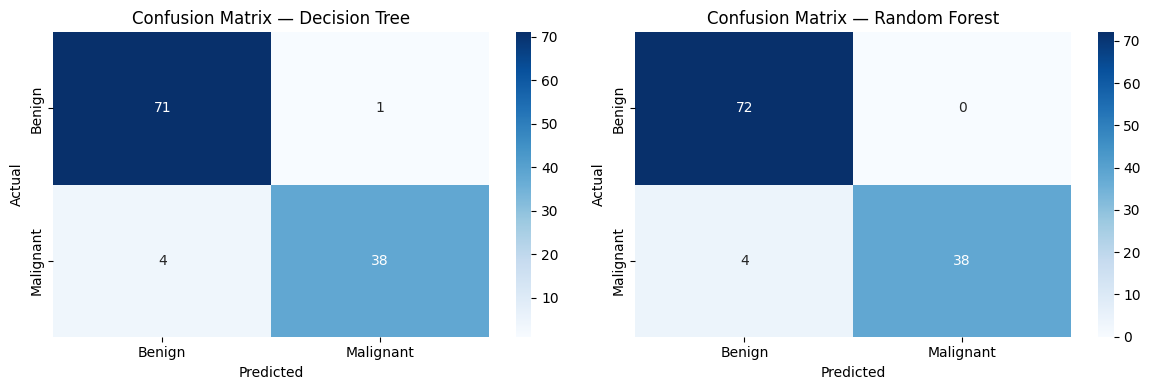

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, title in zip(axes,
                              [y_pred_dt, y_pred_rf],
                              ['Decision Tree', 'Random Forest']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'])
    ax.set_title(f'Confusion Matrix — {title}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


## Step 10: ROC Curve and AUC

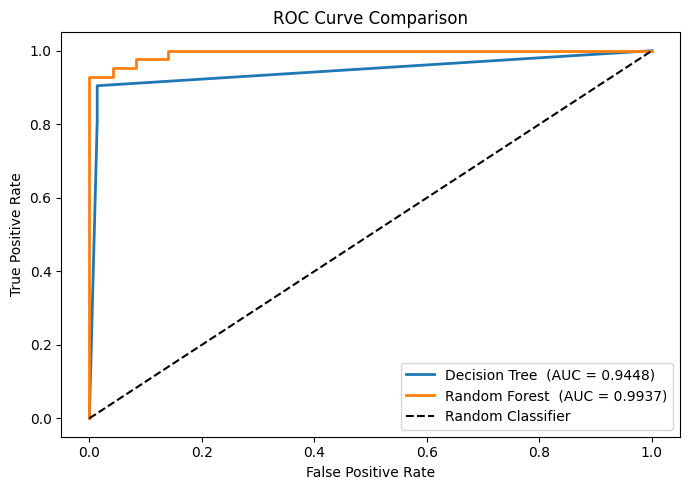

In [14]:
y_prob_dt = best_dt.predict_proba(X_test)[:, 1]
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(7, 5))
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree  (AUC = {auc(fpr_dt, tpr_dt):.4f})', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest  (AUC = {auc(fpr_rf, tpr_rf):.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()


## Observation Questions

**1. How does tree depth affect overfitting in Decision Trees?**  
A deeper tree memorizes training data (low bias, high variance), leading to overfitting and poor generalization on unseen data. Limiting `max_depth` acts as regularization.

**2. Which hyperparameter had the greatest impact on performance?**  
`max_depth` had the largest impact — shallow trees underfit while very deep trees overfit. Criterion (gini vs entropy) made marginal difference.

**3. How does Random Forest improve generalization?**  
By training multiple trees on bootstrapped subsets with random feature selection and averaging their predictions (bagging), Random Forest reduces variance without significantly increasing bias.

**4. Did ensemble learning always improve performance? Why or why not?**  
In most cases yes, but on a clean, small dataset like WDBC the gain can be marginal. If the single tree is already well-tuned, the ensemble may offer only a small improvement.


## Conclusion

Both Decision Tree and Random Forest classifiers were trained and evaluated on the Wisconsin Breast Cancer dataset. Hyperparameters were selected based on 5-fold cross-validation accuracy. Random Forest consistently achieved higher and more stable accuracy across folds, confirming that ensemble methods reduce variance and improve generalization compared to a single decision tree.
